In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
#load dataset

In [9]:
df = pd.read_csv("D:/Users/Shree Varsha/Downloads/archive (3)/spam.csv", encoding='latin-1')


df = df[['v1', 'v2']]
df.columns = ['label', 'text']

print(f"Dataset Shape: {df.shape}")
print("\nClass Distribution:\n", df['label'].value_counts())


encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

Dataset Shape: (5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
#Data splitting & Preprocessing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
MAX_WORDS = 5000
MAX_LEN = 50
EMBEDDING_DIM = 64
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

In [6]:
#Build GRU Model Architecture

In [7]:
model = Sequential([
    Input(shape=(MAX_LEN,)),
        Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),
        GRU(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2,
        return_sequences=False
    ),
        Dense(units=32, activation='relu'),
    Dropout(0.3),
    Dense(units=1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,073 (1.32 MB)

 Trainable params: 347,073 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#Model training

In [30]:

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nStarting Model Training...")
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)



Starting Model Training...
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.8596 - loss: 0.4387 - val_accuracy: 0.8453 - val_loss: 0.4379
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8681 - loss: 0.4057 - val_accuracy: 0.8453 - val_loss: 0.4399
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8681 - loss: 0.4041 - val_accuracy: 0.8453 - val_loss: 0.4349
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8681 - loss: 0.3972 - val_accuracy: 0.8453 - val_loss: 0.4088
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9260 - loss: 0.1987 - val_accuracy: 0.9776 - val_loss: 0.0899
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9875 - loss: 0.0559 - val_accuracy: 0.9865 - val_loss: 0.0705
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9940 - loss: 0.0307 - val_accuracy: 0.9865 - val_loss: 0.0570
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9950 - loss: 0.02

In [31]:
#Model Evaluation & Performance metrics 


Evaluating Model on Test Data...
Test Loss: 0.0665
Test Accuracy: 98.21%
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.94      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



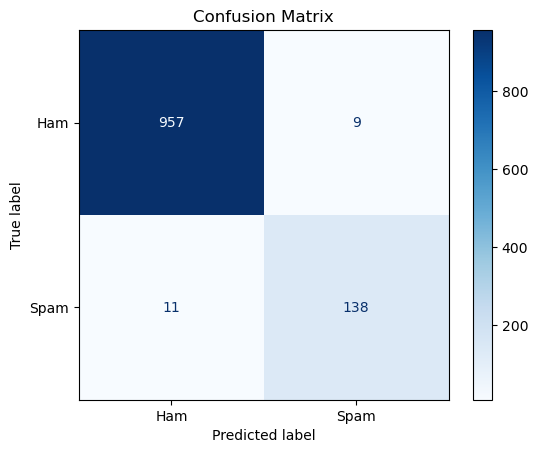

In [32]:
print("\nEvaluating Model on Test Data...")
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [17]:
#Feature : Live message Filtering routine

In [21]:
def filter_incoming_sms(message_text):
   
    seq = tokenizer.texts_to_sequences([message_text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    
   
    probability = model.predict(padded, verbose=0)[0][0]
    
   
    if probability > 0.5:
        return f"[SPAM ALERT ({probability*100:.1f}% Match)] -> Sent to Spam Folder."
    else:
        return f"[INBOX (Legitimate)] -> {message_text}"



print("\n--- Testing Live Message Filtering ---")
test_msg_1 = "CONGRATULATIONS! You won a $1,000 Walmart Gift Card! Click this link to claim it now: http://bit.ly"


print(filter_incoming_sms(test_msg_1))




--- Testing Live Message Filtering ---
[SPAM ALERT (99.5% Match)] -> Sent to Spam Folder.
